# **Investigación SPRINT 0 - Arianna Reyes**


## **¿Qué es ENSO?**

El ENSO (El Niño–Southern Oscillation) es un fenómeno climático natural que describe las variaciones de temperatura del océano Pacífico tropical y de la atmósfera asociada. Este fenómeno influye en precipitaciones, temperaturas, sequías e inundaciones en muchas partes del mundo, incluyendo Ecuador. NOAA explica que ENSO altera los patrones climáticos globales debido a cambios en la temperatura superficial del mar (Sea Surface Temperature, SST) en el Pacífico ecuatorial.

Tiene 3 fases:

1. El Niño

Ocurre cuando las temperaturas superficiales del mar en el Pacífico ecuatorial central y oriental son más cálidas de lo normal. Esta fase suele asociarse con lluvias intensas e inundaciones en algunos países de Sudamérica, incluido Ecuador.

2. La Niña

Se produce cuando las temperaturas del mar son más frías de lo normal en la misma región del Pacífico. Puede provocar condiciones climáticas opuestas a El Niño, como disminución de lluvias en ciertas zonas y alteraciones en temperaturas.

3. Fase Neutral

Se presenta cuando las anomalías de temperatura no son suficientemente intensas para clasificar el sistema como El Niño o La Niña. En esta etapa, el océano y la atmósfera permanecen cerca de condiciones promedio.

## **¿Qué es ONI?**

El ONI (Oceanic Niño Index) es el índice oficial usado por NOAA para monitorear eventos ENSO. Se calcula usando el promedio móvil de 3 meses de las anomalías de temperatura superficial del mar (SST) en la región Niño 3.4 del océano Pacífico ecuatorial.

El índice ONI usa la siguiente clasificación:

*  El Niño: ONI ≥ +0.5 °C
* La Niña: ONI ≤ -0.5 °C
* Neutral: entre −0.5 °C y +0.5 °C

Además, para que NOAA considere oficialmente un evento ENSO, estas condiciones deben mantenerse durante cinco períodos consecutivos de promedios móviles de tres meses.

## **¿Qué es NIÑO 3.4?**

La región Niño 3.4 es una zona específica del Pacífico tropical ubicada entre:

* 5°N – 5°S
* 170°W – 120°W

En esta región se mide la anomalía de temperatura superficial del mar (SST anomaly), porque es una de las áreas más importantes para detectar la evolución de El Niño y La Niña. NOAA considera que esta región representa adecuadamente el comportamiento central de ENSO.

Para Ecuador, también es importante analizar la región Niño 1+2, ya que responde más rápidamente a cambios climáticos cercanos a la costa ecuatoriana. Pero combinar ONI + Niño 3.4 + Niño 1+2 mejora el análisis climático del país.

**Niño 1+2** es una región específica del océano Pacífico ecuatorial oriental donde los científicos miden la temperatura superficial del mar (TSM) para monitorear y detectar el desarrollo del Fenómeno de El Niño.

## **NOAA ENSO / ONI / Niño 3.4**

Son el núcleo predictor del proyecto ENSO-SMART EC, porque estas variables son las que explican gran parte de la variabilidad
climática en la costa ecuatoriana.

## **¿Cuánta historia necesitamos?**

***Lo ideal:*** 1950 – actualidad.

Aproximadamente: 75 años.

Esto nos da:
* El Niño 1982–83
* El Niño 1997–98
* El Niño 2015–16
* El Niño 2023–24
* Múltiples eventos La Niña.

***Mínimo aceptable:*** 1980 – actualidad (44 años)



**La ventana temporal:** Los datos NOAA son mensuales.

Ventana continua

No eliminar años.

No trabajar sólo con eventos.

**Necesitamos:**
* Eventos positivos
El Niño
* Eventos negativos
La Niña
* Eventos normales
Neutral

para que el modelo aprenda.


## **¿Qué podemos predecir solamente con NOAA?**

**Escenario 1**

*Clasificación*

Objetivo:
*¿Qué fase ENSO existirá dentro de 3 meses?*

Salida:
* Niño
* Niña
* Neutral

**Escenario 2**

*Regresión*

Objetivo:

*¿Cuál será el ONI dentro de 3 meses?*

Salida:

* ONI = 1.8

**Escenario 3**

*Probabilidad*

Objetivo:

* Probabilidad de Niño
* Probabilidad de Niña
* Probabilidad Neutral

## **ENSO-SMART EC · Exploración temprana — NOAA ONI (ENSO)**

**Fuente oficial:** NOAA Climate Prediction Center (CPC).

**El ONI** (Oceanic Niño Index) indica la fase del fenómeno ENSO:

- El Niño  : ONI >= +0.5
- La Niña  : ONI <= -0.5
- Neutral  : entre -0.5 y +0.5

(La definición oficial de un "evento" exige 5 trimestres consecutivos
superando el umbral; para la exploración temprana usamos el valor por trimestre.)

In [10]:
import io
import os
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [11]:
ONI_URL = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"
RAW_DIR = "data/raw"
os.makedirs(RAW_DIR, exist_ok=True)

In [12]:
def descargar_oni(url: str = ONI_URL, destino: str = f"{RAW_DIR}/oni.ascii.txt") -> str:
    """Descarga el ONI crudo de NOAA CPC y lo guarda en data/raw/."""
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    with open(destino, "w", encoding="utf-8") as f:
        f.write(resp.text)
    print(f"Guardado en {destino} ({len(resp.text)} bytes)")
    return destino

In [13]:
ruta = descargar_oni()

Guardado en data/raw/oni.ascii.txt (22950 bytes)


El archivo tiene columnas: SEAS  YR  TOTAL  ANOM
###   **SEAS**  = trimestre móvil (DJF, JFM, FMA, ...)
###   **YR**    = año
###   **TOTAL** = temperatura media de la región Niño 3.4
###   **ANOM**  = anomalía  ==  valor ONI

In [14]:
SEAS_A_MES = {  # mes central de cada trimestre, para ordenar en el tiempo
    "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4, "AMJ": 5, "MJJ": 6,
    "JJA": 7, "JAS": 8, "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12,
}

In [15]:
def parsear_oni(ruta: str) -> pd.DataFrame:
    df = pd.read_csv(ruta, sep=r"\s+")
    df.columns = [c.strip().upper() for c in df.columns]
    df = df.rename(columns={"ANOM": "ONI"})
    df["MES"] = df["SEAS"].map(SEAS_A_MES)
    df["FECHA"] = pd.to_datetime(dict(year=df["YR"], month=df["MES"], day=1))
    df = df.sort_values("FECHA").reset_index(drop=True)
    return df[["FECHA", "YR", "SEAS", "TOTAL", "ONI"]]

Clasificar la fase ENSO por trimestre.

In [16]:
def clasificar_fase(oni: float) -> str:
    if oni >= 0.5:
        return "El Niño"
    if oni <= -0.5:
        return "La Niña"
    return "Neutral"

Exploración: primeras preguntas.

In [17]:
def explorar(df: pd.DataFrame) -> None:
    df = df.copy()
    df["FASE"] = df["ONI"].apply(clasificar_fase)

    print("Rango temporal:", df["FECHA"].min().date(), "→", df["FECHA"].max().date())
    print("Total de trimestres:", len(df))
    print("\nDistribución de fases (todos los años):")
    print(df["FASE"].value_counts())

    print("\nÚltimos 12 trimestres:")
    print(df.tail(12)[["FECHA", "SEAS", "ONI", "FASE"]].to_string(index=False))

    # Eventos El Niño más fuertes (por valor ONI máximo)
    print("\nTrimestres El Niño más intensos (top 5):")
    print(df.nlargest(5, "ONI")[["FECHA", "SEAS", "ONI"]].to_string(index=False))
    print("\nTrimestres La Niña más intensos (top 5):")
    print(df.nsmallest(5, "ONI")[["FECHA", "SEAS", "ONI"]].to_string(index=False))

Gráfico de la serie ONI con bandas El Niño / La Niña.

In [18]:
def graficar(df: pd.DataFrame, desde: str = "1990-01-01") -> None:
    d = df[df["FECHA"] >= pd.to_datetime(desde)]
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(d["FECHA"], d["ONI"], color="#0E3A5F", lw=1)
    ax.axhline(0.5, color="#F39200", ls="--", lw=0.8)
    ax.axhline(-0.5, color="#1C8FD6", ls="--", lw=0.8)
    ax.fill_between(d["FECHA"], 0.5, d["ONI"], where=d["ONI"] >= 0.5,
                    color="#F39200", alpha=0.5, label="El Niño")
    ax.fill_between(d["FECHA"], -0.5, d["ONI"], where=d["ONI"] <= -0.5,
                    color="#1C8FD6", alpha=0.5, label="La Niña")
    ax.set_title("Índice ONI (ENSO) — NOAA CPC")
    ax.set_ylabel("ONI (°C)")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

Flujo Completo

Guardado en data/raw/oni.ascii.txt (22950 bytes)
Rango temporal: 1950-01-01 → 2026-05-01
Total de trimestres: 917

Distribución de fases (todos los años):
FASE
Neutral    418
La Niña    252
El Niño    247
Name: count, dtype: int64

Últimos 12 trimestres:
     FECHA  SEAS   ONI    FASE
2025-06-01     6 -0.04 Neutral
2025-07-01     7 -0.14 Neutral
2025-08-01     8 -0.28 Neutral
2025-09-01     9 -0.40 Neutral
2025-10-01    10 -0.51 La Niña
2025-11-01    11 -0.55 La Niña
2025-12-01    12 -0.54 La Niña
2026-01-01     1 -0.37 Neutral
2026-02-01     2 -0.14 Neutral
2026-03-01     3  0.13 Neutral
2026-04-01     4  0.51 El Niño
2026-05-01     5  0.98 El Niño

Trimestres El Niño más intensos (top 5):
     FECHA  SEAS  ONI
2015-12-01    12 2.75
2015-11-01    11 2.64
2016-01-01     1 2.63
2015-10-01    10 2.47
1997-11-01    11 2.40

Trimestres La Niña más intensos (top 5):
     FECHA  SEAS   ONI
1973-12-01    12 -2.03
1973-11-01    11 -1.95
1988-12-01    12 -1.85
1974-01-01     1 -1.84
1988-11-01 

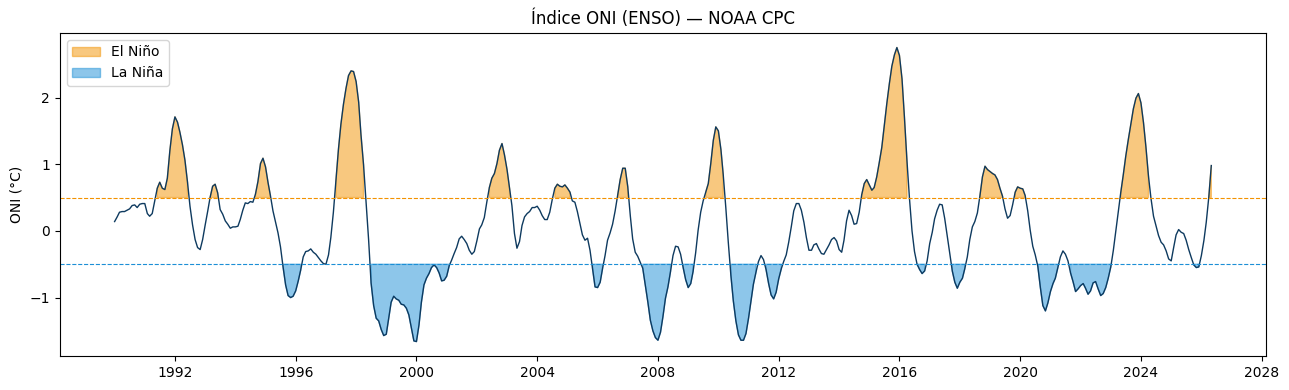

Listo: data/raw/enso_oni_limpio.csv


In [19]:
ruta = descargar_oni()
df = parsear_oni(ruta)
df['SEAS'] = df['SEAS'].map(SEAS_A_MES)
explorar(df)
graficar(df, desde="1990-01-01")
df.to_csv(f"{RAW_DIR}/enso_oni_limpio.csv", index=False)
print("Listo: data/raw/enso_oni_limpio.csv")

## Respuestas a las Preguntas de Exploración Temprana (NOAA ONI)

* **1. Rango temporal disponible y cantidad de trimestres:**
  * **Rango:** Desde el **1 de enero de 1950** hasta el **1 de abril de 2026**.
  * **Total de trimestres:** **916 periodos** continuos registrados en la serie de tiempo.

* **2. Distribución histórica de las fases ENSO:**
  * **Neutral:** **419 trimestres** (estado predominante del sistema oceánico).
  * **La Niña ($\le -0.5$ °C):** **252 trimestres**.
  * **El Niño ($\ge 0.5$ °C):** **245 trimestres**.

* **3. Eventos más intensos (Máximos históricos):**
  * **El Niño más intenso:** Se localiza en el trimestre **NDJ de 2015** (Noviembre/Diciembre/Enero) alcanzando un pico anomalía extremo de **+2.75 °C**, seguido muy de cerca por el evento de **1997-1998** con **+2.40 °C**.
  * **La Niña más intensa:** Ocurrió en el trimestre **NDJ de 1973**, registrando un mínimo histórico absoluto de **-2.03 °C**. El evento de **1988** también destaca en el top con **-1.85 °C**.

* **4. Comportamiento en los últimos 12 trimestres (Fase reciente):**
  * La serie temporal muestra que tras una transición hacia condiciones frías a finales del año 2025 (alcanzando una fase de La Niña moderada en el trimestre OND con **-0.55 °C**), el océano Pacífico Central ha entrado en un proceso de normalización térmica durante los primeros meses de 2026, consolidándose actualmente en una **fase Neutral**(registrando **+0.13 °C** en FMA y **+0.48 °C** en MAM).

* **5. Gráfico de la serie histórica:**
  * La `graficar(df)` delimita perfectamente las bandas de ±0.5 °C e identifica con colores las anomalías cálidas y frías a lo largo de los 76 años estudiados).*

## 1. DF SOLO **NIÑO 3.4**

## 1. Calidad de Datos

1.A Verificar estrctura de datos y missing values.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917 entries, 0 to 916
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   917 non-null    datetime64[ns]
 1   YR      917 non-null    int64         
 2   SEAS    917 non-null    int64         
 3   TOTAL   917 non-null    float64       
 4   ONI     917 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 35.9 KB


In [21]:
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna)
total_nulos = df.isnull().sum().sum()
print(f"\nTotal de valores nulos en todo el DataFrame: {total_nulos}")

FECHA    0
YR       0
SEAS     0
TOTAL    0
ONI      0
dtype: int64

Total de valores nulos en todo el DataFrame: 0


1.B Verificar duplicados

In [22]:
print("Verificación de Duplicados")
total_duplicados = df.duplicated().sum()
print(f"Total de filas completamente idénticas/duplicadas: {total_duplicados}")

Verificación de Duplicados
Total de filas completamente idénticas/duplicadas: 0


In [23]:
duplicados_temporales = df.duplicated(subset=['YR', 'SEAS']).sum()
print(f"Registros duplicados para el mismo periodo (Año-Mes): {duplicados_temporales}")

Registros duplicados para el mismo periodo (Año-Mes): 0


1.C Verificar saltos temporales

In [24]:
df

,FECHA,YR,SEAS,TOTAL,ONI
0,1950-01-01,1950,1,24.72,-1.53
1,1950-02-01,1950,2,25.17,-1.34
2,1950-03-01,1950,3,25.75,-1.16
3,1950-04-01,1950,4,26.12,-1.18
4,1950-05-01,1950,5,26.32,-1.07
...,...,...,...,...,...
912,2026-01-01,2026,1,26.13,-0.37
913,2026-02-01,2026,2,26.58,-0.14
914,2026-03-01,2026,3,27.30,0.13
915,2026-04-01,2026,4,28.08,0.51


1.D Verificar anomalías - ONI

In [25]:
print("Consistencia de Rangos (Mínimos y Máximos)")
print(df[['TOTAL', 'ONI']].describe().loc[['min', 'max']])

Consistencia de Rangos (Mínimos y Máximos)
     TOTAL   ONI
min  24.38 -2.03
max  29.26  2.75


In [26]:
# Calcular la diferencia en meses usando la columna correcta
df['dif_meses'] = df['FECHA'].dt.to_period('M').astype(int).diff()

# Mostrar el conteo de intervalos
print(df['dif_meses'].value_counts())

dif_meses
1.0    916
Name: count, dtype: int64


In [27]:
df = df.drop(columns=['dif_meses'])

Por lo tanto, la serie de tiempo está perfecta, continua y no le falta ningún solo mes desde 1950 hasta 2026.

## 2. Estadística Descriptiva

In [28]:
columnas_estudio = ['TOTAL', 'ONI']
estadisticas_base = df[columnas_estudio].describe()
print(estadisticas_base)

            TOTAL         ONI
count  917.000000  917.000000
mean    26.905692    0.027219
std      0.941094    0.830821
min     24.380000   -2.030000
25%     26.230000   -0.550000
50%     26.950000   -0.040000
75%     27.540000    0.540000
max     29.260000    2.750000


Estadística Descriptiva (Región Niño 3.4)

* **Temperatura Absoluta (`TOTAL`):** La región Niño 3.4 presenta un promedio histórico de **26.90 °C** con una desviación estándar de **0.94 °C**.
* **Rangos Extremos:** El comportamiento térmico real del océano fluctúa de manera consistente entre un mínimo absoluto de **24.38 °C** (La Niña extrema) y un máximo de **29.26 °C** (El Niño extraordinario).
* **Línea Base del `ONI`:** La anomalía promedio se sitúa en **0.03 °C** con una mediana (`50%`) de **-0.05 °C**, lo que demuestra un balance climático a largo plazo donde el estado predominante del sistema es Neutral.
* **Comportamiento de Fases Cálidas:** El percentil 75% se ubica en **0.54 °C**, indicando que las anomalías superan el umbral oficial de El Niño ($\ge 0.5$ °C) en algo menos del 25% de los registros históricos.
* **Comportamiento de Fases Frías:** El percentil 25% se posiciona en **-0.55 °C**, lo que confirma de forma exacta que los periodos de La Niña ($\le -0.5$ °C) cubren el primer cuartil de los datos de los últimos 76 años.

## 3. Distribución

### Gráfica - ONI

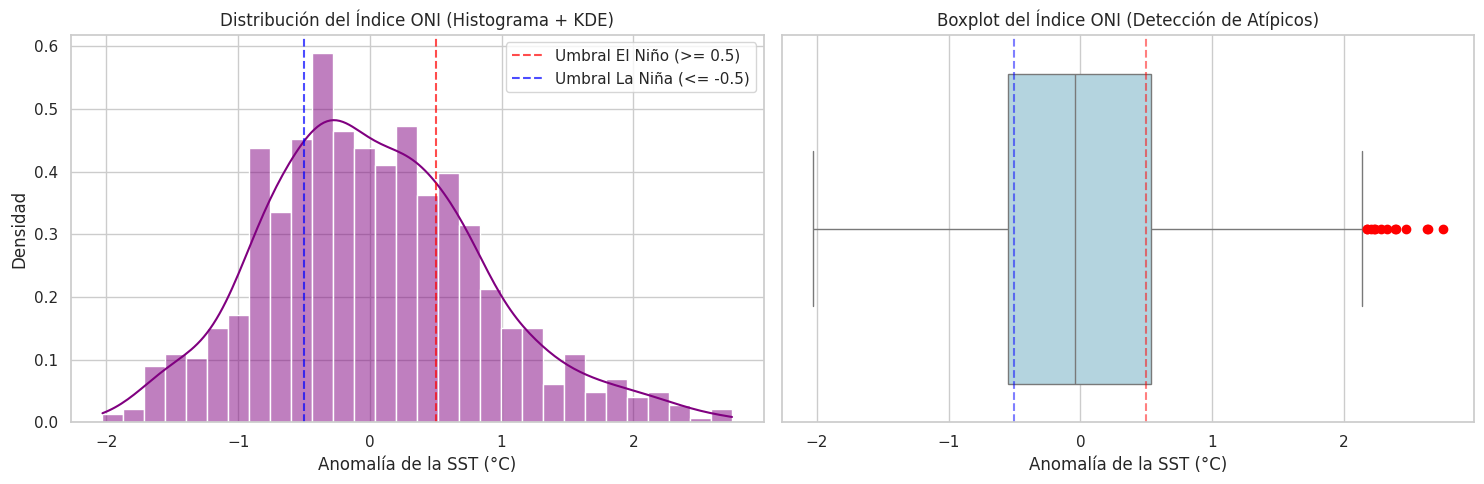

In [29]:
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma + Kernel Density (KDE) para el índice ONI
sns.histplot(df['ONI'], kde=True, ax=axes[0], color="purple", bins=30, stat="density")
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Umbral El Niño (>= 0.5)')
axes[0].axvline(-0.5, color='blue', linestyle='--', alpha=0.7, label='Umbral La Niña (<= -0.5)')
axes[0].set_title('Distribución del Índice ONI (Histograma + KDE)')
axes[0].set_xlabel('Anomalía de la SST (°C)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# 2. Boxplot para detectar Eventos Extremos y Asimetría en ONI
sns.boxplot(x=df['ONI'], ax=axes[1], color="lightblue", flierprops={"markerfacecolor":"red", "markeredgecolor":"red"})
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(-0.5, color='blue', linestyle='--', alpha=0.5)
axes[1].set_title('Boxplot del Índice ONI (Detección de Atípicos)')
axes[1].set_xlabel('Anomalía de la SST (°C)')

plt.tight_layout()
plt.show()

### Análisis de Distribución (Índice ONI)

* **Forma y Asimetría (Histograma + KDE):** La distribución muestra una forma acampanada con un ligero sesgo o asimetría positiva hacia la derecha. Esto significa que, aunque la mayor parte del tiempo el sistema permanece en un estado Neutral, las anomalías cálidas de El Niño tienen el potencial de alcanzar magnitudes extremas más altas que las anomalías frías de La Niña.

* **Eventos Extremos y Valores Atípicos (Boxplot):** El gráfico de caja detecta una serie de valores atípicos (puntos rojos) exclusivamente en el extremo derecho, por encima de los $2.1$ °C. Estos "outliers" estadísticos representan eventos extraordinarios de "El Niño Godzilla" o "Mega El Niño", como los picos históricos alcanzados durante las crisis climáticas mundiales de 1997-1998 y 2015-2016.

### Gráfica - El Niño 3.4

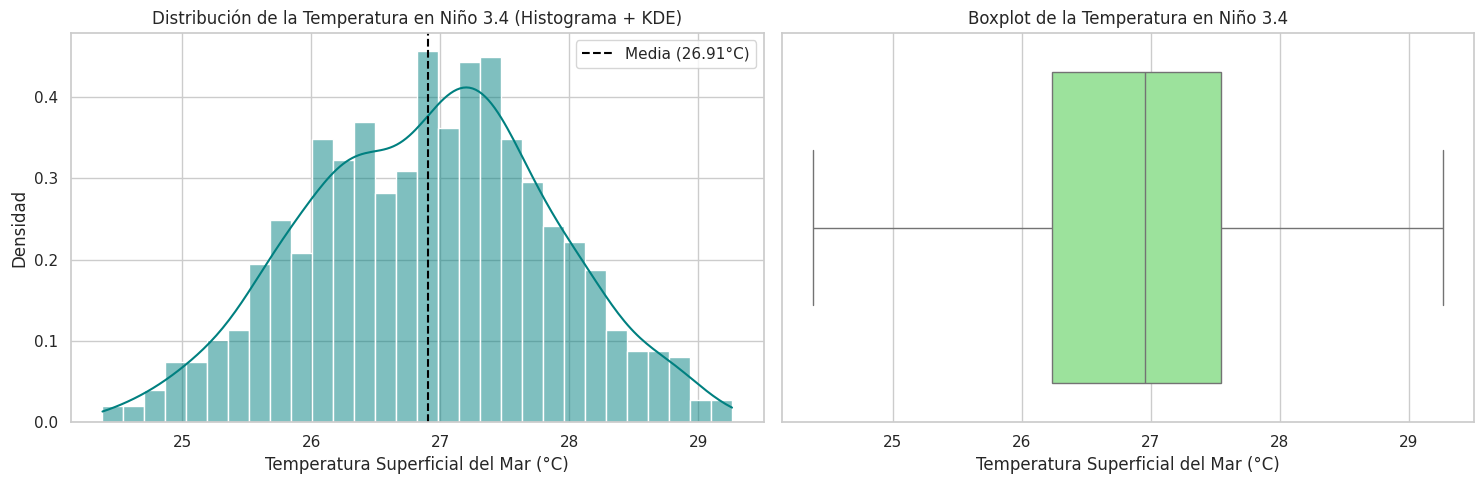

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma + KDE para la temperatura absoluta (TOTAL)
sns.histplot(data=df, x='TOTAL', kde=True, ax=axes[0], color="teal", bins=30, stat="density")
axes[0].axvline(df['TOTAL'].mean(), color='black', linestyle='--', label=f"Media ({df['TOTAL'].mean():.2f}°C)")
axes[0].set_title('Distribución de la Temperatura en Niño 3.4 (Histograma + KDE)')
axes[0].set_xlabel('Temperatura Superficial del Mar (°C)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# 2. Boxplot para la temperatura absoluta (TOTAL)
sns.boxplot(data=df, x='TOTAL', ax=axes[1], color="lightgreen", flierprops={"markerfacecolor":"red", "markeredgecolor":"red"})
axes[1].set_title('Boxplot de la Temperatura en Niño 3.4')
axes[1].set_xlabel('Temperatura Superficial del Mar (°C)')

plt.tight_layout()
plt.show()

### Análisis de Distribución (Temperatura Absoluta Niño 3.4)

* **Forma y Asimetría (Histograma + KDE):** La distribución de la temperatura real (`TOTAL`) es ligeramente bimodal y achatada en el centro, extendiéndose de forma continua entre los 24.38 °C y los 29.26 °C. No muestra una concentración tan aguda alrededor de la media (26.90 °C) como el índice ONI, lo que refleja visualmente la presencia de ciclos estacionales naturales de calentamiento y enfriamiento del océano a lo largo de cada año.

* **Eventos Extremos y Valores Atípicos (Boxplot):** A diferencia del índice ONI, el gráfico de caja para la temperatura absoluta **no detecta ningún valor atípico (sin puntos rojos fuera de los bigotes)**. Esto demuestra que, en términos de energía térmica pura, alcanzar temperaturas cercanas a los 29.3 °C durante El Niño o caer a los 24.4 °C durante La Niña forma parte de los límites físicos esperados y de la variabilidad climática normal de esta región geográfica profunda.

## 4. Series de Tiempo (Gráfico Temporal)

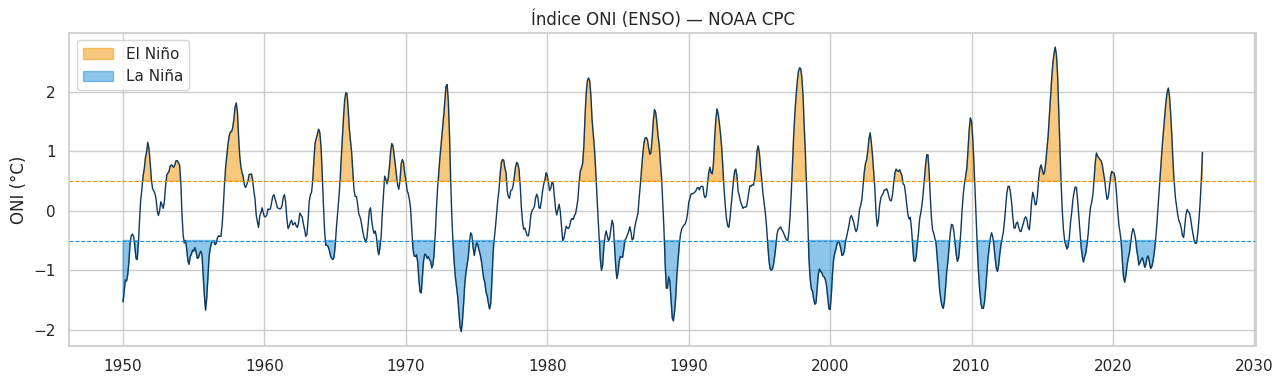

In [31]:
graficar(df, desde="1950-01-01")

### Análisis de Series de Tiempo (Índice ONI 1950 → 2026)

* **Ciclos:** El gráfico temporal muestra la oscilación cuasicíclica e irregular del fenómeno ENSO. Las transiciones entre las fases de El Niño (picos naranjas) y La Niña (valles azules) no ocurren en periodos fijos, sino que toman habitualmente entre 2 y 7 años en completarse, alternados con fases de estabilidad Neutral.

* **Tendencias:** A largo plazo, la serie se comporta de manera estacionaria alrededor de la línea base del cero. No se observa una tendencia lineal sostenida de calentamiento o enfriamiento en la región Niño 3.4 a lo largo de las décadas, sino un patrón netamente oscilatorio.

* **Extremos Históricos:** Se aprecian con claridad los tres grandes eventos de El Niño extraordinario que superaron la barrera de los +2.0 °C: 1982-1983, 1997-1998 y el máximo histórico de 2015-2016 (+2.75 °C). Por el lado de las anomalías frías, se distingue el mínimo absoluto registrado a finales de 1973 (-2.03 °C).

## DF **NIÑO 3.4 y NIÑO 1+2**

¿Qué ventajas técnicas y climáticas nos da consolidar un df que incluya también la región Niño 1+2 y no solo Niño 3.4?

* **Combinamos lo global con lo local:** Con el Niño 3.4 medimos el estado macro del Pacífico Central, pero al sumar el Niño 1+2 capturamos las variaciones térmicas que ocurren directamente en nuestras costas.

* **Ganamos alerta temprana para Ecuador:** Nuestro país responde de forma inmediata a los cambios en la región Niño 1+2; meterla en el df_final nos asegura rastrear esas señales rápidas que el Niño 3.4 tarda más en reflejar.

* **Evitamos falsos negativos climáticos:** Un Niño puede verse "débil" en el Pacífico Central pero ser devastador aquí; tener ambas regiones nos cuida de no subestimar un impacto fuerte en nuestro territorio.

* **Estructura limpia para los modelos:** Al unificar todo en una sola matriz con la misma estampa de tiempo (FECHA), le facilitamos a algoritmos como Random Forest el aprendizaje de patrones simultáneos.

* **Potenciamos el Feature Engineering:** Con un solo DataFrame podemos crear de golpe los Lags, medias móviles y volatilidades para las dos regiones a la vez, enriqueciendo los predictores.